<a href="https://colab.research.google.com/github/ksantos-helo/Challende_TelecomX_parte2_BR/blob/main/TelecomX_parte2_BR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1️⃣ IMPORTAÇÃO DE BIBLIOTECAS


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE

# 2️⃣ CARREGAMENTO DO DATASET (via GitHub)

In [64]:
import pandas as pd

url = "https://raw.githubusercontent.com/ksantos-helo/Challende_TelecomX_parte2_BR/main/telecom_tratado.csv"

df = pd.read_csv(url)

df.head()

print("Dimensão do dataset:", df.shape)

Dimensão do dataset: (7043, 21)


# 3️⃣ ANÁLISE DE CORRELAÇÃO

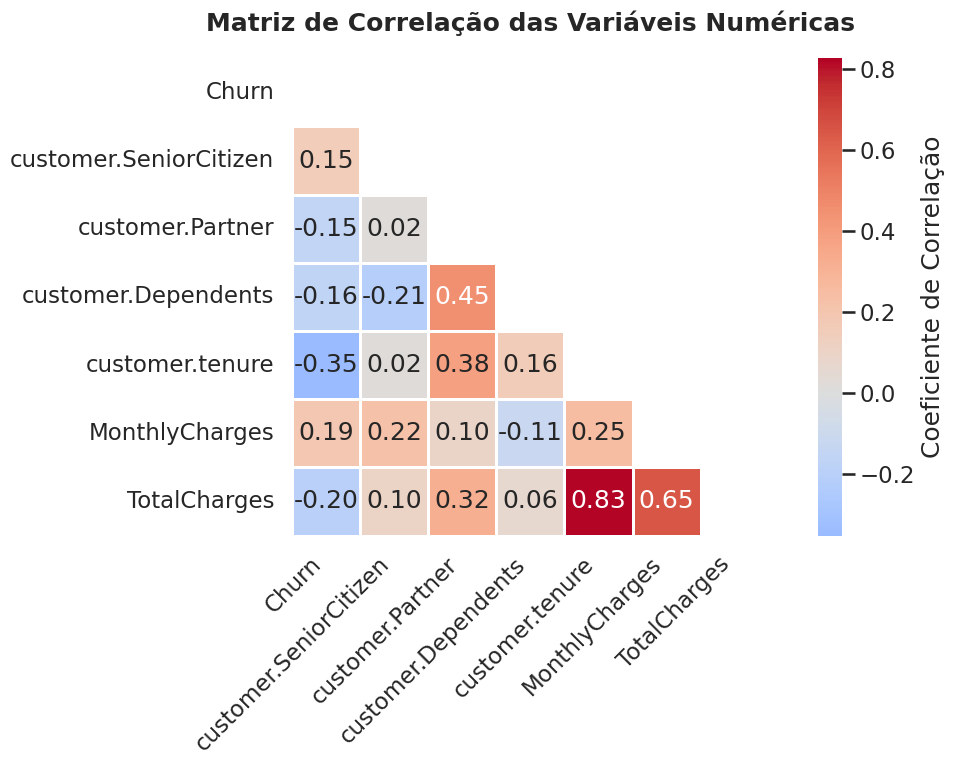

In [55]:

corr = df.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12,8))

sns.set_style("white")
sns.set_context("talk")

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=1,
    square=True,
    cbar_kws={"label": "Coeficiente de Correlação"}
)

plt.title(
    "Matriz de Correlação das Variáveis Numéricas",
    fontsize=18,
    weight="bold",
    pad=20
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# 4️⃣ REMOÇÃO DE VARIÁVEL IRRELEVANTE

In [56]:
# customerID é apenas identificador
df = df.drop(columns=['customerID'])

# 5️⃣ ENCODING DE VARIÁVEIS CATEGÓRICAS

In [57]:
categorical_cols = df.select_dtypes(include=['object']).columns

df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

print(df_encoded.shape)
print(df_encoded.columns)

(7043, 31)
Index(['Churn', 'customer.SeniorCitizen', 'customer.Partner',
       'customer.Dependents', 'customer.tenure', 'MonthlyCharges',
       'TotalCharges', 'customer.gender_Male', 'phone.PhoneService_Yes',
       'phone.MultipleLines_No phone service', 'phone.MultipleLines_Yes',
       'internet.InternetService_Fiber optic', 'internet.InternetService_No',
       'internet.OnlineSecurity_No internet service',
       'internet.OnlineSecurity_Yes',
       'internet.OnlineBackup_No internet service',
       'internet.OnlineBackup_Yes',
       'internet.DeviceProtection_No internet service',
       'internet.DeviceProtection_Yes',
       'internet.TechSupport_No internet service', 'internet.TechSupport_Yes',
       'internet.StreamingTV_No internet service', 'internet.StreamingTV_Yes',
       'internet.StreamingMovies_No internet service',
       'internet.StreamingMovies_Yes', 'account.Contract_One year',
       'account.Contract_Two year', 'account.PaperlessBilling_Yes',
       'ac

# 6️⃣ SEPARAÇÃO DE VARIÁVEIS PREDITORAS E ALVO

In [58]:
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]


# 7️⃣ DIVISÃO TREINO / TESTE

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# 8️⃣ ANÁLISE DE DESBALANCEAMENTO

Distribuição original das classes:
Churn
0    4139
1    1495
Name: count, dtype: int64


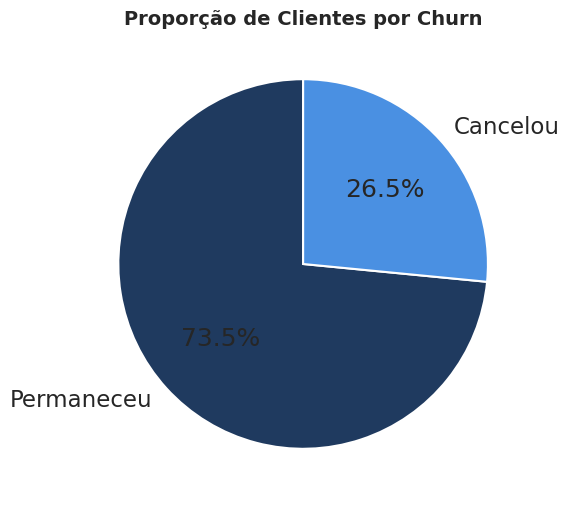

In [60]:
print("Distribuição original das classes:")
print(y_train.value_counts())

plt.figure(figsize=(6,6))

colors = ['#1f3a5f', '#4a90e2']

df_encoded['Churn'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['Permaneceu','Cancelou'],
    colors=colors,
    startangle=90
)

plt.title('Proporção de Clientes por Churn', fontsize=14, weight='bold')
plt.ylabel('')
plt.show()


# 9️⃣ BALANCEAMENTO COM SMOTE

In [61]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Distribuição após SMOTE:")
print(y_train_smote.value_counts())

Distribuição após SMOTE:
Churn
0    4139
1    4139
Name: count, dtype: int64


# 🔟 VISUALIZAÇÃO DO BALANCEAMENTO

/tmp/ipykernel_699/2413045876.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/tmp/ipykernel_699/2413045876.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Permaneceu", "Cancelou"])


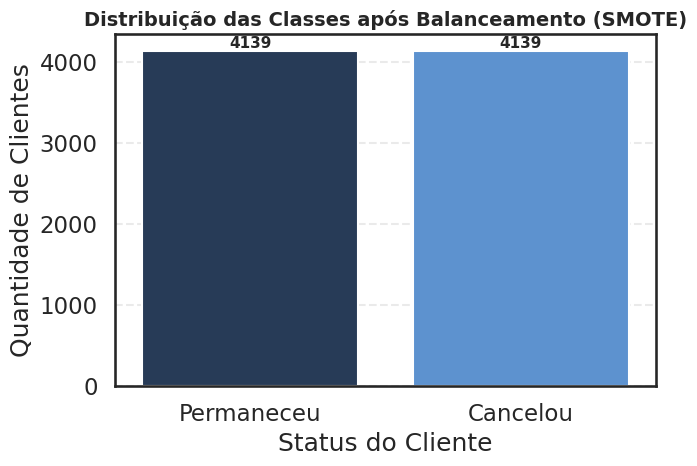

In [62]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    x=y_train_smote,
    palette=["#1f3a5f", "#4a90e2"]
)

plt.title(
    "Distribuição das Classes após Balanceamento (SMOTE)",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Status do Cliente")
plt.ylabel("Quantidade de Clientes")

ax.set_xticklabels(["Permaneceu", "Cancelou"])

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11,
        weight='bold'
    )

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# 1️⃣1️⃣ PADRONIZAÇÃO DOS DADOS

In [63]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled[:5])

[[-0.40227424  1.30550564 -0.52918533  1.3588908   0.91950393  1.57894614
  -1.17187022  0.29434149 -0.34071201  1.04548877  0.9263568  -0.45096849
  -0.45096849  1.60782517 -0.45096849  1.30482917 -0.45096849 -0.76658244
  -0.45096849 -0.63654879 -0.45096849 -0.90230668 -0.45096849  1.1126105
  -0.48492647 -0.4627516   0.65382528  1.9004471  -0.95904057 -0.56832934]
 [-0.40227424 -0.76598673  1.88969714 -0.64223997 -1.70154549 -0.83328147
   0.85333681  0.29434149 -0.34071201 -0.95649042 -1.07949766  2.2174498
   2.2174498  -0.62195817  2.2174498  -0.76638385  2.2174498  -0.76658244
   2.2174498  -0.63654879  2.2174498  -0.90230668  2.2174498  -0.89878713
  -0.48492647  2.16098658 -1.52946059 -0.52619197 -0.95904057 -0.56832934]
 [-0.40227424 -0.76598673 -0.52918533 -1.05914222  0.44087751 -0.86774448
  -1.17187022  0.29434149 -0.34071201 -0.95649042  0.9263568  -0.45096849
  -0.45096849  1.60782517 -0.45096849 -0.76638385 -0.45096849  1.30449114
  -0.45096849 -0.63654879 -0.45096849 